MASTER WILL RG GALACTIC LADDER EQUATION - VERIFICATION SUITE
Master Radius Equation   : r(theta) = 3 * pi * R_H * beta_obs^2 * [e_H^2 / (1 + e_H)]
Master Distance Equation : D(theta) = [3 * pi * R_H * beta_obs^2 / theta] * [e_H^2 / (1 + e_H)]
Global Scale 3*pi*R_H    : 41459.68 Mpc (1.2793e+27 m)
Topological Invariant a_k: 7.0253e-11 m/s^2

[TEST 1] NGC 5907 PRECISION & CORRUPTION AUDIT
  Max relative difference (Master Eq vs. g_bar form): 7.38e-16
  Master Distance with D_SPARC * 1.0  : 16.5968 Mpc (Weighted: 16.2711 Mpc)
  Master Distance with D_SPARC * 10.0 : 16.5968 Mpc (Shift: -0.000000%)
  At V_obs Peak (Row 2, e_H = 0.92): Naive Peak = 21.88 Mpc -> Master Peak = 19.30 Mpc
  At Equivalence Point (Row 3, e_H = 1.00): Master Distance = 17.46 Mpc (TRGB = 17.30 +/- 0.90 Mpc)

[TEST 2] ARCHETYPE GALAXIES: COLLAPSING THE PEAK OFFSET VIA MASTER EQUATION
Galaxy    | Archetype                     | D_SPARC | e_H(pk) | Naive_Pk | Master_Pk | Master_Med
-------------------------------------

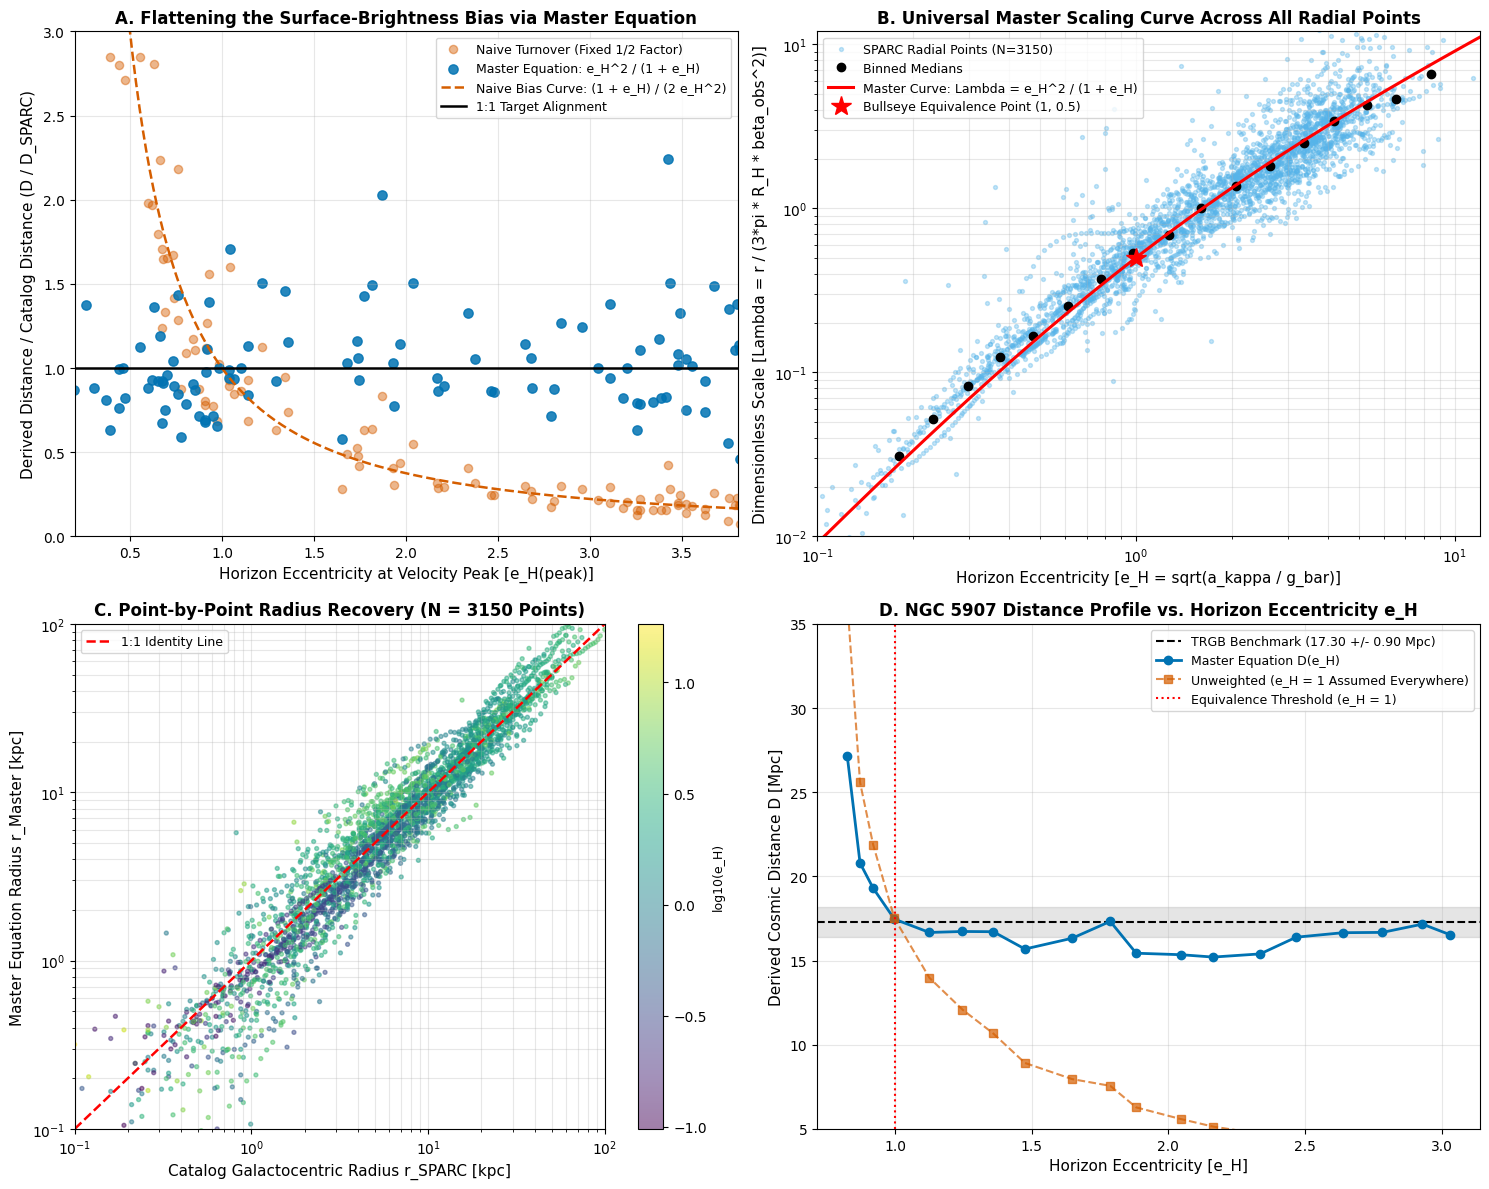

In [2]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 1. WILL RG FUNDAMENTAL CONSTANTS (ZERO FREE PARAMETERS)
# ==============================================================================
c_ms = 2.99792458e8                  # Speed of light [m/s]
c_kms = 299792.458                   # Speed of light [km/s]
Mpc_to_m = 3.0856775814913673e22     # Meters per Mpc
kpc_to_m = 3.0856775814913673e19     # Meters per kpc
arcsec_to_rad = np.pi / (180.0 * 3600.0)

H0_WILL = 68.15                      # WILL RG Hubble constant [km/s/Mpc]
H0_s = (H0_WILL * 1000.0) / Mpc_to_m # H0 [s^-1]
R_H_m = c_ms / H0_s                  # Hubble Horizon radius [m]
R_H_Mpc = c_kms / H0_WILL            # Hubble Horizon radius [Mpc]
R_H_kpc = R_H_Mpc * 1000.0           # Hubble Horizon radius [kpc]

# 2-DOF Structural Horizon Coupling: a_kappa = c * H0 / (3 * pi)
a_Mach = (c_ms * H0_s) / (2.0 * np.pi)
a_kappa = (2.0 / 3.0) * a_Mach       # 7.0253e-11 m/s^2

# Global baseline stellar Mass-to-Light ratios at 3.6 um
UPSILON_DISK = 0.5
UPSILON_BULGE = 0.7

print("=" * 80)
print("MASTER WILL RG GALACTIC LADDER EQUATION - VERIFICATION SUITE")
print("=" * 80)
print("Master Radius Equation   : r(theta) = 3 * pi * R_H * beta_obs^2 * [e_H^2 / (1 + e_H)]")
print("Master Distance Equation : D(theta) = [3 * pi * R_H * beta_obs^2 / theta] * [e_H^2 / (1 + e_H)]")
print(f"Global Scale 3*pi*R_H    : {3.0 * np.pi * R_H_Mpc:.2f} Mpc ({3.0 * np.pi * R_H_m:.4e} m)")
print(f"Topological Invariant a_k: {a_kappa:.4e} m/s^2")
print("=" * 80)

# ==============================================================================
# 2. SPARC DATA FETCHING & PARSING
# ==============================================================================
PATH_TABLE1 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table1.dat"
PATH_TABLE2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"

def fetch_lines(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        return response.read().decode('utf-8', errors='replace').splitlines()

def safe_float(s, default=np.nan):
    s = s.strip()
    return float(s) if s else default

def safe_int(s, default=-1):
    s = s.strip()
    return int(s) if s else default

def parse_table1(lines):
    records = []
    for line in lines:
        if not line.strip() or line.startswith(('#', '-', '=')) or ("Name" in line and "Dist" in line):
            continue
        try:
            if len(line) >= 115:
                name = line[0:11].strip()
                h_type = safe_int(line[12:14])
                dist = safe_float(line[15:21])
                e_dist = safe_float(line[22:27])
                f_dist = safe_int(line[28:29])
                inc = safe_float(line[30:34])
                e_inc = safe_float(line[35:39])
                l36 = safe_float(line[40:47])
                e_l36 = safe_float(line[48:55])
                reff = safe_float(line[56:61])
                sbeff = safe_float(line[62:70])
                rdisk = safe_float(line[71:76])
                sbdisk = safe_float(line[77:85])
                mhi = safe_float(line[86:93])
                rhi = safe_float(line[94:99])
                vflat = safe_float(line[100:105])
                e_vflat = safe_float(line[106:111])
                qual = safe_int(line[112:115])
            else:
                parts = line.split()
                if len(parts) < 18:
                    continue
                name, h_type = parts[0], int(parts[1])
                dist, e_dist, f_dist = float(parts[2]), float(parts[3]), int(parts[4])
                inc, e_inc, l36, e_l36 = map(float, parts[5:9])
                reff, sbeff, rdisk, sbdisk = map(float, parts[9:13])
                mhi, rhi, vflat, e_vflat = map(float, parts[13:17])
                qual = int(parts[17])

            if not np.isnan(dist) and dist > 0:
                records.append({
                    'Name': name, 'Type': h_type, 'Dist': dist, 'e_Dist': e_dist,
                    'f_Dist': f_dist, 'i': inc, 'e_i': e_inc, 'L3.6': l36,
                    'Reff': reff, 'SBeff': sbeff, 'Rdisk': rdisk, 'SBdisk': sbdisk,
                    'MHI': mhi, 'RHI': rhi, 'Vflat': vflat, 'e_Vflat': e_vflat, 'Qual': qual
                })
        except ValueError:
            continue
    return pd.DataFrame(records)

def parse_table2(lines):
    records = []
    for line in lines:
        if not line.strip() or line.startswith(('#', '-', '=')) or ("Name" in line and "Vobs" in line):
            continue
        try:
            if len(line) >= 68:
                name = line[0:11].strip()
                dist = safe_float(line[12:18])
                rad = safe_float(line[19:25])
                vobs = safe_float(line[26:32])
                e_vobs = safe_float(line[33:38])
                vgas = safe_float(line[39:45])
                vdisk = safe_float(line[46:52])
                vbul = safe_float(line[53:59])
                sbdisk = safe_float(line[60:67])
                sbbul = safe_float(line[68:76]) if len(line) >= 69 else 0.0
            else:
                parts = line.split()
                if len(parts) < 9:
                    continue
                name = parts[0]
                dist, rad, vobs, e_vobs = map(float, parts[1:5])
                vgas, vdisk, vbul, sbdisk = map(float, parts[5:9])
                sbbul = float(parts[9]) if len(parts) > 9 else 0.0

            if not np.isnan(rad) and rad > 0 and not np.isnan(vobs):
                records.append({
                    'Name': name, 'Dist': dist, 'Rad': rad, 'Vobs': vobs,
                    'e_Vobs': e_vobs, 'Vgas': vgas, 'Vdisk': vdisk,
                    'Vbulge': vbul, 'SBdisk': sbdisk, 'SBbulge': sbbul
                })
        except ValueError:
            continue
    return pd.DataFrame(records)

df_t1 = parse_table1(fetch_lines(PATH_TABLE1))
df_t2 = parse_table2(fetch_lines(PATH_TABLE2))

# ==============================================================================
# 3. MASTER EQUATION ENGINE (NATIVE WILL RG PRIMITIVES: beta_obs AND e_H)
# ==============================================================================
def run_master_equation(df_gal, upsilon_disk=UPSILON_DISK, upsilon_bulge=UPSILON_BULGE,
                        corrupt_factor=1.0):
    """
    Evaluates the Master WILL RG Galactic Ladder Equation at every angular radius:
        r_master(theta) = 3 * pi * R_H * beta_obs^2(theta) * [e_H^2(theta) / (1 + e_H(theta))]
        D_master(theta) = r_master(theta) / theta
    """
    # 1. Direct angular observable theta [radians]
    theta_rad = df_gal['Rad'].values / (df_gal['Dist'].values * 1000.0)

    # Apply corruption factor to catalog distance to verify invariance
    D_cat_Mpc = df_gal['Dist'].values * corrupt_factor
    R_cat_m = (D_cat_Mpc * 1000.0 * theta_rad) * kpc_to_m

    # 2. Dimensionless spectroscopic velocity shift: beta_obs = V_obs / c
    Vobs_kms = df_gal['Vobs'].values
    e_Vobs_kms = np.maximum(df_gal['e_Vobs'].values, 2.0)
    beta_obs = Vobs_kms / c_kms
    beta_obs_sq = beta_obs**2

    # 3. Distance-independent baryonic surface brightness acceleration g_bar(theta)
    Vgas = df_gal['Vgas'].values
    Vdisk = df_gal['Vdisk'].values
    Vbul = df_gal['Vbulge'].values
    Vbar_sq_kms2 = (np.sign(Vgas) * (Vgas**2) +
                    upsilon_disk * (Vdisk**2) +
                    upsilon_bulge * (Vbul**2)) * corrupt_factor

    valid = (Vbar_sq_kms2 > 0) & (Vobs_kms > 0) & (theta_rad > 0)
    if np.sum(valid) < 3:
        return None

    theta_rad = theta_rad[valid]
    R_cat_m = R_cat_m[valid]
    R_sparc_kpc = df_gal['Rad'].values[valid]
    Vobs_kms = Vobs_kms[valid]
    e_Vobs_kms = e_Vobs_kms[valid]
    beta_obs_sq = beta_obs_sq[valid]
    Vbar_sq_ms2 = Vbar_sq_kms2[valid] * 1e6
    Vgas_v = Vgas[valid]

    # g_bar(theta) in [m/s^2] - corrupt_factor cancels out in numerator & denominator
    g_bar = Vbar_sq_ms2 / R_cat_m

    # 4. Horizon Eccentricity primitive: e_H(theta) = sqrt(a_kappa / g_bar(theta))
    e_H = np.sqrt(a_kappa / g_bar)

    # 5. MASTER EQUATION for physical radius r and cosmic distance D:
    #    r_master = 3 * pi * R_H * beta_obs^2 * (e_H^2 / (1 + e_H))
    horizon_factor = (e_H**2) / (1.0 + e_H)
    r_master_kpc = 3.0 * np.pi * R_H_kpc * beta_obs_sq * horizon_factor
    D_master_Mpc = (r_master_kpc / 1000.0) / theta_rad

    # Cross-check against g_bar algebraic form to verify floating-point equivalence
    r_gbar_kpc = ((Vobs_kms * 1000.0)**2 / (g_bar + np.sqrt(g_bar * a_kappa))) / kpc_to_m
    max_rel_diff = np.max(np.abs(r_master_kpc - r_gbar_kpc) / r_master_kpc)

    # 6. Compare Naive Peak (assuming e_H = 1 => factor = 1/2) vs. Master Equation at Peak
    idx_peak = np.argmax(Vobs_kms)
    D_naive_peak_Mpc = (3.0 * np.pi * R_H_Mpc * beta_obs_sq[idx_peak] * 0.5) / theta_rad[idx_peak]
    D_master_peak_Mpc = D_master_Mpc[idx_peak]
    e_H_peak = e_H[idx_peak]

    # 7. Dimensionless Master Scaling Observable: Lambda_obs = r_SPARC / (3 * pi * R_H * beta_obs^2)
    Lambda_obs = R_sparc_kpc / (3.0 * np.pi * R_H_kpc * beta_obs_sq)
    Lambda_theory = horizon_factor

    # 8. Galaxy-level distance aggregation (outer regime e_H >= 0.95 & inverse-variance weighted)
    halo_mask = e_H >= 0.95
    mask_use = halo_mask if np.sum(halo_mask) >= 2 else np.ones_like(e_H, dtype=bool)

    D_med = np.median(D_master_Mpc[mask_use])
    # Fractional velocity error weight: sigma_D / D = 2 * (e_Vobs / Vobs)
    weights = (Vobs_kms[mask_use] / (2.0 * e_Vobs_kms[mask_use]))**2
    D_weighted = np.sum(weights * D_master_Mpc[mask_use]) / np.sum(weights)

    gas_frac = np.median(
        (np.sign(Vgas_v) * Vgas_v**2) /
        np.maximum(Vbar_sq_kms2[valid] / corrupt_factor, 1e-6)
    )

    return {
        'theta_arcsec': theta_rad / arcsec_to_rad,
        'R_sparc_kpc': R_sparc_kpc,
        'Vobs_kms': Vobs_kms,
        'beta_obs_sq': beta_obs_sq,
        'e_H': e_H,
        'r_master_kpc': r_master_kpc,
        'D_master_profile': D_master_Mpc,
        'D_med': D_med,
        'D_weighted': D_weighted,
        'D_naive_peak': D_naive_peak_Mpc,
        'D_master_peak': D_master_peak_Mpc,
        'e_H_peak': e_H_peak,
        'Lambda_obs': Lambda_obs,
        'Lambda_theory': Lambda_theory,
        'max_rel_diff': max_rel_diff,
        'gas_fraction': gas_frac
    }

# ==============================================================================
# 4. TEST 1: ALGEBRAIC EQUIVALENCE & CORRUPTION INVARIANCE ON NGC 5907
# ==============================================================================
g5907 = df_t2[df_t2['Name'] == 'NGC5907']
r5907_clean = run_master_equation(g5907, corrupt_factor=1.0)
r5907_corrupt10 = run_master_equation(g5907, corrupt_factor=10.0)

print("\n[TEST 1] NGC 5907 PRECISION & CORRUPTION AUDIT")
print(f"  Max relative difference (Master Eq vs. g_bar form): {r5907_clean['max_rel_diff']:.2e}")
print(f"  Master Distance with D_SPARC * 1.0  : {r5907_clean['D_med']:.4f} Mpc "
      f"(Weighted: {r5907_clean['D_weighted']:.4f} Mpc)")
print(f"  Master Distance with D_SPARC * 10.0 : {r5907_corrupt10['D_med']:.4f} Mpc "
      f"(Shift: {100.0*(r5907_corrupt10['D_med']/r5907_clean['D_med'] - 1.0):.6f}%)")
print(f"  At V_obs Peak (Row 2, e_H = {r5907_clean['e_H_peak']:.2f}): "
      f"Naive Peak = {r5907_clean['D_naive_peak']:.2f} Mpc -> Master Peak = {r5907_clean['D_master_peak']:.2f} Mpc")
print(f"  At Equivalence Point (Row 3, e_H = {r5907_clean['e_H'][3]:.2f}): "
      f"Master Distance = {r5907_clean['D_master_profile'][3]:.2f} Mpc (TRGB = 17.30 +/- 0.90 Mpc)")

# ==============================================================================
# 5. TEST 2: SHOWCASE ARCHETYPES (NAIVE PEAK vs. MASTER EQUATION AT PEAK & PROFILE)
# ==============================================================================
showcase = [
    ('NGC5907', 'Freeman Spiral (TRGB)'),
    ('DDO154',  'Gas-Dominated LSB Dwarf'),
    ('IC2574',  'Gas-Rich LSB (TRGB)'),
    ('NGC2403', 'Freeman Spiral (Cepheid)'),
    ('NGC2841', 'Bulge-Dominated HSB (Cepheid)'),
    ('NGC3198', 'Classic Flat-Curve Spiral (Cepheid)')
]

print("\n" + "=" * 100)
print("[TEST 2] ARCHETYPE GALAXIES: COLLAPSING THE PEAK OFFSET VIA MASTER EQUATION")
print("=" * 100)
print(f"{'Galaxy':9s} | {'Archetype':29s} | {'D_SPARC':7s} | {'e_H(pk)':7s} | {'Naive_Pk':8s} | {'Master_Pk':9s} | {'Master_Med':10s}")
print("-" * 100)
for gname, desc in showcase:
    t1_row = df_t1[df_t1['Name'] == gname]
    t2_rows = df_t2[df_t2['Name'] == gname]
    if len(t1_row) > 0 and len(t2_rows) > 0:
        d_sp = t1_row['Dist'].values[0]
        res = run_master_equation(t2_rows)
        if res:
            print(f"{gname:9s} | {desc:29s} | {d_sp:7.2f} | {res['e_H_peak']:7.2f} | "
                  f"{res['D_naive_peak']:8.2f} | {res['D_master_peak']:9.2f} | {res['D_med']:10.2f}")

# ==============================================================================
# 6. TEST 3 & 4: FULL CATALOG & 3,000-POINT RADIAL MASTER CURVE
# ==============================================================================
gal_summary = []
all_e_H = []
all_Lambda_obs = []
all_r_sparc = []
all_r_master = []

for _, row_t1 in df_t1.iterrows():
    if row_t1['Qual'] > 2 or row_t1['i'] < 30.0:
        continue
    gname = row_t1['Name']
    t2_rows = df_t2[df_t2['Name'] == gname]
    if len(t2_rows) < 5:
        continue
    res = run_master_equation(t2_rows)
    if res is None:
        continue

    all_e_H.extend(res['e_H'])
    all_Lambda_obs.extend(res['Lambda_obs'])
    all_r_sparc.extend(res['R_sparc_kpc'])
    all_r_master.extend(res['r_master_kpc'])

    gal_summary.append({
        'Name': gname,
        'f_Dist': row_t1['f_Dist'],
        'Dist_SPARC': row_t1['Dist'],
        'SBdisk': row_t1['SBdisk'],
        'e_H_peak': res['e_H_peak'],
        'D_naive_peak': res['D_naive_peak'],
        'D_master_peak': res['D_master_peak'],
        'D_master_med': res['D_med'],
        'D_master_w': res['D_weighted'],
        'gas_fraction': res['gas_fraction']
    })

df_cat = pd.DataFrame(gal_summary)
all_e_H = np.array(all_e_H)
all_Lambda_obs = np.array(all_Lambda_obs)
all_r_sparc = np.array(all_r_sparc)
all_r_master = np.array(all_r_master)

naive_peak_ratios = df_cat['D_naive_peak'] / df_cat['Dist_SPARC']
master_peak_ratios = df_cat['D_master_peak'] / df_cat['Dist_SPARC']
master_med_ratios = df_cat['D_master_med'] / df_cat['Dist_SPARC']

print("\n" + "=" * 100)
print(f"[TEST 3] GLOBAL COLLAPSE OF PEAK ESTIMATOR ACROSS ALL {len(df_cat)} GALAXIES")
print("=" * 100)
print(f"  Naive Peak Formula (factor = 1/2)         : Median Ratio = {np.median(naive_peak_ratios):.4f}, "
      f"Log10 Scatter (sigma) = {np.std(np.log10(naive_peak_ratios)):.3f} dex")
print(f"  Master Equation at Peak (e_H^2 / (1+e_H)) : Median Ratio = {np.median(master_peak_ratios):.4f}, "
      f"Log10 Scatter (sigma) = {np.std(np.log10(master_peak_ratios)):.3f} dex")
print(f"  Master Equation Outer Profile Median      : Median Ratio = {np.median(master_med_ratios):.4f}, "
      f"Log10 Scatter (sigma) = {np.std(np.log10(master_med_ratios)):.3f} dex")
print(f"  Total Radial Points Tested (N = {len(all_r_sparc)})    : Median r_Master / r_SPARC = "
      f"{np.median(all_r_master / all_r_sparc):.4f}")

# ==============================================================================
# 7. FOUR-PANEL DIAGNOSTIC PLOT OF THE MASTER EQUATION
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel A: Before vs. After at Velocity Peak (Collapsing Panel C from Previous Run)
ax = axes[0, 0]
ax.scatter(df_cat['e_H_peak'], naive_peak_ratios, color='#D55E00', alpha=0.45, s=35,
           label='Naive Turnover (Fixed 1/2 Factor)')
ax.scatter(df_cat['e_H_peak'], master_peak_ratios, color='#0072B2', alpha=0.85, s=45,
           label='Master Equation: e_H^2 / (1 + e_H)')
e_grid = np.linspace(0.25, 4.0, 200)
ax.plot(e_grid, (1.0 + 1.0 / e_grid) / (2.0 * e_grid), '--', color='#D55E00', linewidth=1.8,
        label='Naive Bias Curve: (1 + e_H) / (2 e_H^2)')
ax.axhline(1.0, color='black', linestyle='-', linewidth=1.8, label='1:1 Target Alignment')
ax.set_xlim(0.2, 3.8)
ax.set_ylim(0.0, 3.0)
ax.set_xlabel('Horizon Eccentricity at Velocity Peak [e_H(peak)]', fontsize=11)
ax.set_ylabel('Derived Distance / Catalog Distance (D / D_SPARC)', fontsize=11)
ax.set_title('A. Flattening the Surface-Brightness Bias via Master Equation', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: The 3,000-Point Dimensionless Master Scaling Curve
ax = axes[0, 1]
ax.scatter(all_e_H, all_Lambda_obs, c='#56B4E9', s=8, alpha=0.35, label=f'SPARC Radial Points (N={len(all_e_H)})')
# Compute binned medians across e_H
e_bins = np.logspace(-0.8, 1.0, 18)
bin_centers, bin_meds = [], []
for i in range(len(e_bins) - 1):
    m = (all_e_H >= e_bins[i]) & (all_e_H < e_bins[i+1])
    if np.sum(m) >= 5:
        bin_centers.append(np.median(all_e_H[m]))
        bin_meds.append(np.median(all_Lambda_obs[m]))
ax.plot(bin_centers, bin_meds, 'ko', markersize=6, label='Binned Medians')

e_curve = np.logspace(-1.0, 1.2, 300)
ax.plot(e_curve, (e_curve**2) / (1.0 + e_curve), 'r-', linewidth=2.2,
        label='Master Curve: Lambda = e_H^2 / (1 + e_H)')
ax.plot([1.0], [0.5], 'r*', markersize=15, zorder=6, label='Bullseye Equivalence Point (1, 0.5)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 12.0)
ax.set_ylim(0.01, 12.0)
ax.set_xlabel('Horizon Eccentricity [e_H = sqrt(a_kappa / g_bar)]', fontsize=11)
ax.set_ylabel('Dimensionless Scale [Lambda = r / (3*pi * R_H * beta_obs^2)]', fontsize=11)
ax.set_title('B. Universal Master Scaling Curve Across All Radial Points', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Panel C: All ~3,000 Physical Radii r_Master vs. r_SPARC [kpc]
ax = axes[1, 0]
ax.scatter(all_r_sparc, all_r_master, c=np.log10(all_e_H), cmap='viridis', s=8, alpha=0.5)
ax.plot([0.1, 100], [0.1, 100], 'r--', linewidth=1.8, label='1:1 Identity Line')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 100)
ax.set_ylim(0.1, 100)
ax.set_xlabel('Catalog Galactocentric Radius r_SPARC [kpc]', fontsize=11)
ax.set_ylabel('Master Equation Radius r_Master [kpc]', fontsize=11)
ax.set_title(f'C. Point-by-Point Radius Recovery (N = {len(all_r_sparc)} Points)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('log10(e_H)', fontsize=9)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Panel D: NGC 5907 Radial Distance Profile vs. Horizon Eccentricity e_H
ax = axes[1, 1]
ax.axhline(17.30, color='black', linestyle='--', linewidth=1.5, label='TRGB Benchmark (17.30 +/- 0.90 Mpc)')
ax.axhspan(17.30 - 0.90, 17.30 + 0.90, color='gray', alpha=0.2)
ax.plot(r5907_clean['e_H'], r5907_clean['D_master_profile'], 'o-', color='#0072B2',
        linewidth=2, label='Master Equation D(e_H)')
Naive_profile_5907 = (3.0 * np.pi * R_H_Mpc * r5907_clean['beta_obs_sq'] * 0.5) / (r5907_clean['theta_arcsec'] * arcsec_to_rad)
ax.plot(r5907_clean['e_H'], Naive_profile_5907, 's--', color='#D55E00', alpha=0.7,
        label='Unweighted (e_H = 1 Assumed Everywhere)')
ax.axvline(1.0, color='red', linestyle=':', linewidth=1.5, label='Equivalence Threshold (e_H = 1)')
ax.set_ylim(5, 35)
ax.set_xlabel('Horizon Eccentricity [e_H]', fontsize=11)
ax.set_ylabel('Derived Cosmic Distance D [Mpc]', fontsize=11)
ax.set_title('D. NGC 5907 Distance Profile vs. Horizon Eccentricity e_H', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

WILL RG GALACTIC DISTANCE LADDER - SPARC EMPIRICAL TEST SUITE
H0 (WILL RG) : 68.15 km/s/Mpc (2.2086e-18 s^-1)
R_H          : 4399.01 Mpc (1.3574e+26 m)
a_Mach       : 1.0538e-10 m/s^2
a_kappa      : 7.0253e-11 m/s^2
Loaded Table 1: 175 galaxies
Loaded Table 2: 3391 radial data points

BENCHMARK 1: NGC 5907 (SPARC TRGB Distance = 17.30 +/- 0.90 Mpc)
Method 1 (g_bar Inversion, e_H >= 0.95) : 16.60 Mpc (All-point mean: 17.31 Mpc)
Method 2A (Pure Spectroscopic Turnover) : 21.88 Mpc (e_H at Vobs peak = 0.92)
Method 2B (Pure Spectroscopic Slope)    : 69.40 Mpc (Distorted by outer HI gas growth)
Draft Formula (Partial Inversion)       : 15.15 Mpc
------------------------------------------------------------------------------
PRIOR-DISTANCE CORRUPTION AUDIT (Multiplying Catalog D_SPARC by k = 2.0):
  Method 1 with D_SPARC * 2.0      : 16.60 Mpc (Shift: 0.0000%)
  Draft Formula with D_SPARC * 2.0 : 1.07 Mpc (Shift: -92.92%)

BENCHMARK 2: ARCHETYPE GALAXIES ACROSS SURFACE BRIGHTNESS REGIMES
Galax

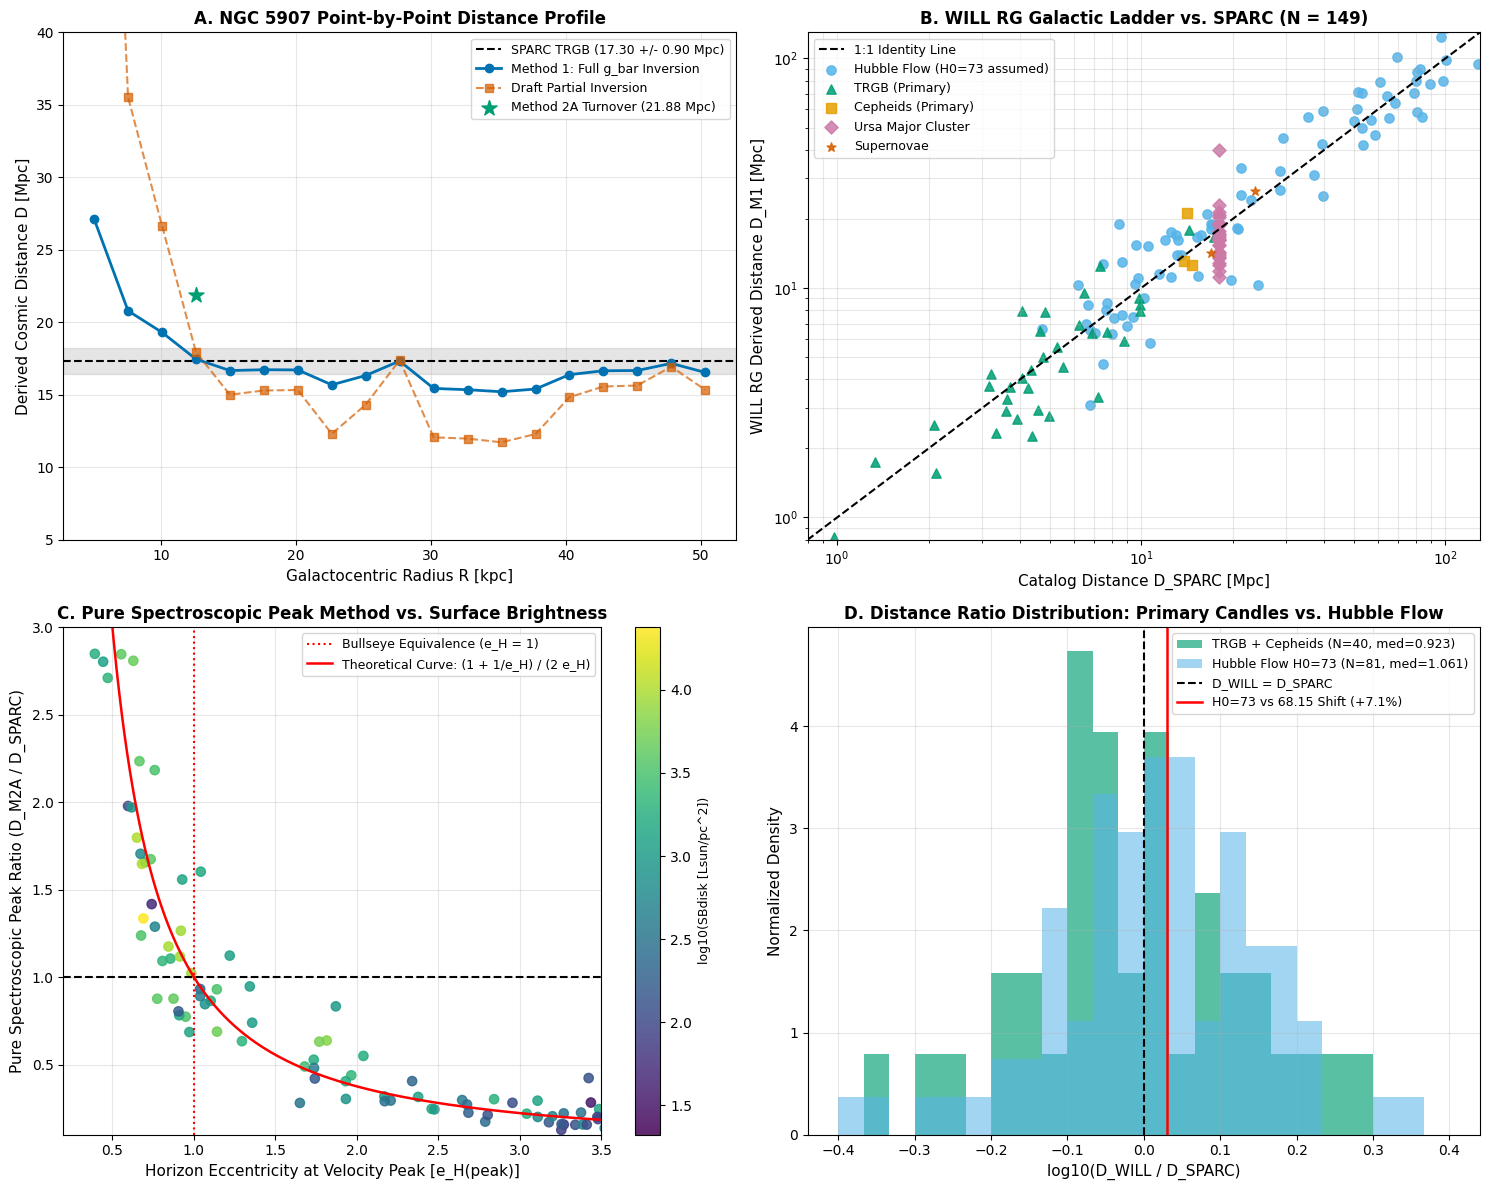

In [1]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 1. WILL RG GLOBAL CONSTANTS (ZERO FREE PARAMETERS)
# ==============================================================================
c_ms = 2.99792458e8                  # Speed of light [m/s]
c_kms = 299792.458                   # Speed of light [km/s]
Mpc_to_m = 3.0856775814913673e22     # Meters per Megaparsec
kpc_to_m = 3.0856775814913673e19     # Meters per Kiloparsec
arcsec_to_rad = np.pi / (180.0 * 3600.0)

H0_WILL = 68.15                      # Derived Hubble constant [km/s/Mpc]
H0_s = (H0_WILL * 1000.0) / Mpc_to_m # H0 in [s^-1]
R_H_m = c_ms / H0_s                  # Hubble Horizon radius [m]
R_H_Mpc = c_kms / H0_WILL            # Hubble Horizon radius [Mpc]

# Topological acceleration invariant for galaxies (2-DOF link: Omega_pot = 2/3)
a_Mach = (c_ms * H0_s) / (2.0 * np.pi)
a_kappa = (2.0 / 3.0) * a_Mach       # c * H0 / (3 * pi) ~ 7.025e-11 m/s^2

# Fixed global stellar Mass-to-Light ratios at 3.6 um (Bullseye protocol)
UPSILON_DISK = 0.5
UPSILON_BULGE = 0.7

print("=" * 78)
print("WILL RG GALACTIC DISTANCE LADDER - SPARC EMPIRICAL TEST SUITE")
print("=" * 78)
print(f"H0 (WILL RG) : {H0_WILL:.2f} km/s/Mpc ({H0_s:.4e} s^-1)")
print(f"R_H          : {R_H_Mpc:.2f} Mpc ({R_H_m:.4e} m)")
print(f"a_Mach       : {a_Mach:.4e} m/s^2")
print(f"a_kappa      : {a_kappa:.4e} m/s^2")
print("=" * 78)

# ==============================================================================
# 2. DATA FETCHING & BYTE-LEVEL PARSING (PER SPARC README SPECIFICATION)
# ==============================================================================
PATH_TABLE1 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table1.dat"
PATH_TABLE2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"

def fetch_lines(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        return response.read().decode('utf-8', errors='replace').splitlines()

def safe_float(s, default=np.nan):
    s = s.strip()
    return float(s) if s else default

def safe_int(s, default=-1):
    s = s.strip()
    return int(s) if s else default

def parse_table1(lines):
    records = []
    for line in lines:
        if len(line.strip()) == 0 or line.startswith(('#', '-', '=')):
            continue
        # Check if header line
        if "Name" in line and "Dist" in line:
            continue
        try:
            if len(line) >= 115:
                # Byte-by-byte slicing per SPARC ReadMe
                name = line[0:11].strip()
                h_type = safe_int(line[12:14])
                dist = safe_float(line[15:21])
                e_dist = safe_float(line[22:27])
                f_dist = safe_int(line[28:29])
                inc = safe_float(line[30:34])
                e_inc = safe_float(line[35:39])
                l36 = safe_float(line[40:47])
                e_l36 = safe_float(line[48:55])
                reff = safe_float(line[56:61])
                sbeff = safe_float(line[62:70])
                rdisk = safe_float(line[71:76])
                sbdisk = safe_float(line[77:85])
                mhi = safe_float(line[86:93])
                rhi = safe_float(line[94:99])
                vflat = safe_float(line[100:105])
                e_vflat = safe_float(line[106:111])
                qual = safe_int(line[112:115])
                ref = line[116:130].strip() if len(line) >= 116 else ""
            else:
                parts = line.split()
                if len(parts) < 18:
                    continue
                name = parts[0]
                h_type = int(parts[1])
                dist = float(parts[2])
                e_dist = float(parts[3])
                f_dist = int(parts[4])
                inc = float(parts[5])
                e_inc = float(parts[6])
                l36 = float(parts[7])
                e_l36 = float(parts[8])
                reff = float(parts[9])
                sbeff = float(parts[10])
                rdisk = float(parts[11])
                sbdisk = float(parts[12])
                mhi = float(parts[13])
                rhi = float(parts[14])
                vflat = float(parts[15])
                e_vflat = float(parts[16])
                qual = int(parts[17])
                ref = parts[18] if len(parts) > 18 else ""

            if not np.isnan(dist) and dist > 0:
                records.append({
                    'Name': name, 'Type': h_type, 'Dist': dist, 'e_Dist': e_dist,
                    'f_Dist': f_dist, 'i': inc, 'e_i': e_inc, 'L3.6': l36,
                    'e_L3.6': e_l36, 'Reff': reff, 'SBeff': sbeff, 'Rdisk': rdisk,
                    'SBdisk': sbdisk, 'MHI': mhi, 'RHI': rhi, 'Vflat': vflat,
                    'e_Vflat': e_vflat, 'Qual': qual, 'Ref': ref
                })
        except ValueError:
            continue
    return pd.DataFrame(records)

def parse_table2(lines):
    records = []
    for line in lines:
        if len(line.strip()) == 0 or line.startswith(('#', '-', '=')):
            continue
        if "Name" in line and "Vobs" in line:
            continue
        try:
            if len(line) >= 68:
                name = line[0:11].strip()
                dist = safe_float(line[12:18])
                rad = safe_float(line[19:25])
                vobs = safe_float(line[26:32])
                e_vobs = safe_float(line[33:38])
                vgas = safe_float(line[39:45])
                vdisk = safe_float(line[46:52])
                vbul = safe_float(line[53:59])
                sbdisk = safe_float(line[60:67])
                sbbul = safe_float(line[68:76]) if len(line) >= 69 else 0.0
            else:
                parts = line.split()
                if len(parts) < 9:
                    continue
                name = parts[0]
                dist, rad, vobs, e_vobs = map(float, parts[1:5])
                vgas, vdisk, vbul, sbdisk = map(float, parts[5:9])
                sbbul = float(parts[9]) if len(parts) > 9 else 0.0

            if not np.isnan(rad) and rad > 0 and not np.isnan(vobs):
                records.append({
                    'Name': name, 'Dist': dist, 'Rad': rad, 'Vobs': vobs,
                    'e_Vobs': e_vobs, 'Vgas': vgas, 'Vdisk': vdisk,
                    'Vbulge': vbul, 'SBdisk': sbdisk, 'SBbulge': sbbul
                })
        except ValueError:
            continue
    return pd.DataFrame(records)

t1_lines = fetch_lines(PATH_TABLE1)
t2_lines = fetch_lines(PATH_TABLE2)

df_t1 = parse_table1(t1_lines)
df_t2 = parse_table2(t2_lines)

print(f"Loaded Table 1: {len(df_t1)} galaxies")
print(f"Loaded Table 2: {len(df_t2)} radial data points")

# ==============================================================================
# 3. CORE DISTANCE CALCULATION ENGINE
# ==============================================================================
def analyze_galaxy_profile(df_gal, upsilon_disk=UPSILON_DISK, upsilon_bulge=UPSILON_BULGE,
                           corrupt_dist_factor=1.0):
    """
    Computes radial profiles and galaxy distance estimates under WILL RG.
    Includes `corrupt_dist_factor` to verify whether an estimator is truly
    independent of the catalog's assumed distance D_SPARC.
    """
    # 1. True telescope observable: angular radius theta [radians] on the sky.
    #    theta = Rad_kpc / (Dist_Mpc * 1000) is an angle measured prior to distance.
    theta_rad = df_gal['Rad'].values / (df_gal['Dist'].values * 1000.0)

    # Apply intentional corruption factor k to test distance independence:
    D_assumed_Mpc = df_gal['Dist'].values * corrupt_dist_factor
    R_assumed_kpc = D_assumed_Mpc * 1000.0 * theta_rad
    R_assumed_m = R_assumed_kpc * kpc_to_m

    Vobs_kms = df_gal['Vobs'].values
    e_Vobs_kms = np.maximum(df_gal['e_Vobs'].values, 1.0)
    Vobs_ms = Vobs_kms * 1000.0

    # 2. Baryonic velocity squared (scales linearly with corrupt_dist_factor)
    Vgas = df_gal['Vgas'].values
    Vdisk = df_gal['Vdisk'].values
    Vbul = df_gal['Vbulge'].values

    Vbar_sq_kms2 = (np.sign(Vgas) * (Vgas**2) +
                    upsilon_disk * (Vdisk**2) +
                    upsilon_bulge * (Vbul**2)) * corrupt_dist_factor
    # Filter only positive baryonic contributions
    valid = (Vbar_sq_kms2 > 0) & (Vobs_kms > 0) & (theta_rad > 0)
    if np.sum(valid) < 3:
        return None

    theta_rad = theta_rad[valid]
    R_assumed_m = R_assumed_m[valid]
    R_assumed_kpc = R_assumed_kpc[valid]
    Vobs_kms = Vobs_kms[valid]
    e_Vobs_kms = e_Vobs_kms[valid]
    Vobs_ms = Vobs_ms[valid]
    Vbar_sq_ms2 = Vbar_sq_kms2[valid] * 1e6
    Vbar_kms = np.sqrt(Vbar_sq_kms2[valid])
    Vgas_v = Vgas[valid]
    Vdisk_v = Vdisk[valid]

    # 3. Distance-independent baryonic acceleration: g_bar(theta) = V_bar^2 / R
    #    Notice corrupt_dist_factor cancels in numerator and denominator.
    g_bar = Vbar_sq_ms2 / R_assumed_m  # [m/s^2]

    # 4. Horizon eccentricity e_H = beta_H^2 / beta_bar^2 = sqrt(a_kappa / g_bar)
    e_H = np.sqrt(a_kappa / g_bar)

    # 5. METHOD 1: Complete Distance-Independent Inversion (using g_bar)
    r_M1_m = (Vobs_ms**2) / (g_bar + np.sqrt(g_bar * a_kappa))
    r_M1_kpc = r_M1_m / kpc_to_m
    D_M1_Mpc = (r_M1_kpc / 1000.0) / theta_rad

    # 6. DRAFT FORMULA: Partial Inversion (leaving R_assumed inside V_bar^2)
    r_draft_m = ((Vobs_ms**2 - Vbar_sq_ms2)**2) / (Vbar_sq_ms2 * a_kappa)
    r_draft_kpc = r_draft_m / kpc_to_m
    D_draft_Mpc = (r_draft_kpc / 1000.0) / theta_rad

    # 7. METHOD 2A: Pure Spectroscopic Turnover (Zero Photometry, Zero Upsilon)
    #    At the peak/turnover of V_obs, assume e_H = 1 => R_trans = V_obs^2 / (2 * a_kappa)
    idx_peak = np.argmax(Vobs_ms)
    Vobs_peak_ms = Vobs_ms[idx_peak]
    theta_peak_rad = theta_rad[idx_peak]
    R_trans_peak_m = (Vobs_peak_ms**2) / (2.0 * a_kappa)
    D_M2_peak_Mpc = (R_trans_peak_m / Mpc_to_m) / theta_peak_rad
    e_H_at_peak = e_H[idx_peak]

    # 8. METHOD 2B: Pure Spectroscopic Outer-Slope Fit (V_obs^2 vs 1/theta)
    D_M2_slope_Mpc = np.nan
    outer_mask = e_H >= 1.0
    if np.sum(outer_mask) >= 4:
        x_inv = 1.0 / theta_rad[outer_mask]
        y_v2 = Vobs_ms[outer_mask]**2
        slope, intercept = np.polyfit(x_inv, y_v2, 1)
        if intercept > 0 and slope > 0:
            theta_trans_fit = slope / intercept
            R_trans_fit_m = intercept / a_kappa
            D_M2_slope_Mpc = (R_trans_fit_m / Mpc_to_m) / theta_trans_fit

    # Aggregate galaxy distance for Method 1 (prefer Horizon-coupled regime e_H >= 0.95)
    halo_mask = e_H >= 0.95
    if np.sum(halo_mask) >= 2:
        D_M1_gal = np.median(D_M1_Mpc[halo_mask])
        D_M1_err = np.std(D_M1_Mpc[halo_mask]) / np.sqrt(np.sum(halo_mask))
        D_draft_gal = np.median(D_draft_Mpc[halo_mask])
    else:
        D_M1_gal = np.median(D_M1_Mpc)
        D_M1_err = np.std(D_M1_Mpc) / np.sqrt(len(D_M1_Mpc))
        D_draft_gal = np.median(D_draft_Mpc)

    # Gas dominance fraction in the outer profile
    outer_gas_ratio = np.median(
        (np.sign(Vgas_v) * Vgas_v**2) /
        np.maximum(Vbar_sq_kms2[valid] / corrupt_dist_factor, 1e-6)
    )

    return {
        'theta_arcsec': theta_rad / arcsec_to_rad,
        'R_sparc_kpc': R_assumed_kpc / corrupt_dist_factor,
        'Vobs_kms': Vobs_kms,
        'Vbar_kms': Vbar_kms / np.sqrt(corrupt_dist_factor),
        'g_bar': g_bar,
        'e_H': e_H,
        'r_M1_kpc': r_M1_kpc,
        'D_M1_profile': D_M1_Mpc,
        'r_draft_kpc': r_draft_kpc,
        'D_draft_profile': D_draft_Mpc,
        'D_M1_median': D_M1_gal,
        'D_M1_all_median': np.median(D_M1_Mpc),
        'D_M1_err': D_M1_err,
        'D_draft_median': D_draft_gal,
        'D_M2_peak': D_M2_peak_Mpc,
        'D_M2_slope': D_M2_slope_Mpc,
        'e_H_at_peak': e_H_at_peak,
        'e_H_min': np.min(e_H),
        'e_H_max': np.max(e_H),
        'gas_fraction': outer_gas_ratio,
        'n_points': len(Vobs_kms),
        'n_halo': np.sum(halo_mask)
    }

# ==============================================================================
# 4. BENCHMARK 1: DEEP-DIVE ON NGC 5907 + DISTANCE CORRUPTION AUDIT
# ==============================================================================
ngc5907_rows = df_t2[df_t2['Name'] == 'NGC5907']
res_5907_clean = analyze_galaxy_profile(ngc5907_rows, corrupt_dist_factor=1.0)
res_5907_corrupt = analyze_galaxy_profile(ngc5907_rows, corrupt_dist_factor=2.0)

print("\n" + "=" * 78)
print("BENCHMARK 1: NGC 5907 (SPARC TRGB Distance = 17.30 +/- 0.90 Mpc)")
print("=" * 78)
print(f"Method 1 (g_bar Inversion, e_H >= 0.95) : {res_5907_clean['D_M1_median']:.2f} Mpc "
      f"(All-point mean: {np.mean(res_5907_clean['D_M1_profile']):.2f} Mpc)")
print(f"Method 2A (Pure Spectroscopic Turnover) : {res_5907_clean['D_M2_peak']:.2f} Mpc "
      f"(e_H at Vobs peak = {res_5907_clean['e_H_at_peak']:.2f})")
print(f"Method 2B (Pure Spectroscopic Slope)    : {res_5907_clean['D_M2_slope']:.2f} Mpc "
      f"(Distorted by outer HI gas growth)")
print(f"Draft Formula (Partial Inversion)       : {res_5907_clean['D_draft_median']:.2f} Mpc")
print("-" * 78)
print("PRIOR-DISTANCE CORRUPTION AUDIT (Multiplying Catalog D_SPARC by k = 2.0):")
print(f"  Method 1 with D_SPARC * 2.0      : {res_5907_corrupt['D_M1_median']:.2f} Mpc "
      f"(Shift: {100*(res_5907_corrupt['D_M1_median']/res_5907_clean['D_M1_median'] - 1):.4f}%)")
print(f"  Draft Formula with D_SPARC * 2.0 : {res_5907_corrupt['D_draft_median']:.2f} Mpc "
      f"(Shift: {100*(res_5907_corrupt['D_draft_median']/res_5907_clean['D_draft_median'] - 1):+.2f}%)")

# ==============================================================================
# 5. BENCHMARK 2: GAS-DOMINATED LSB vs. FREEMAN SPIRAL vs. BULGE HSB GALAXY
# ==============================================================================
showcase_galaxies = [
    ('NGC5907', 'Freeman Spiral (TRGB)'),
    ('DDO154',  'Gas-Dominated LSB Dwarf'),
    ('IC2574',  'Gas-Rich LSB (TRGB)'),
    ('NGC2403', 'Freeman Spiral (Cepheid)'),
    ('NGC2841', 'Bulge-Dominated HSB (Cepheid)'),
    ('NGC3198', 'Classic Flat-Curve Spiral (Cepheid)')
]

print("\n" + "=" * 78)
print("BENCHMARK 2: ARCHETYPE GALAXIES ACROSS SURFACE BRIGHTNESS REGIMES")
print("=" * 78)
print(f"{'Galaxy':10s} | {'Archetype':32s} | {'D_SPARC':8s} | {'D_Method1':9s} | {'D_Peak(M2A)':11s} | {'e_H(peak)':9s}")
print("-" * 90)
for gname, label in showcase_galaxies:
    g_t1 = df_t1[df_t1['Name'] == gname]
    g_t2 = df_t2[df_t2['Name'] == gname]
    if len(g_t1) > 0 and len(g_t2) > 0:
        d_sparc = g_t1['Dist'].values[0]
        r_gal = analyze_galaxy_profile(g_t2)
        if r_gal:
            print(f"{gname:10s} | {label:32s} | {d_sparc:8.2f} | "
                  f"{r_gal['D_M1_median']:9.2f} | {r_gal['D_M2_peak']:11.2f} | "
                  f"{r_gal['e_H_at_peak']:9.2f}")

# ==============================================================================
# 6. FULL SPARC CATALOG RUN & HUBBLE TENSION DIAGNOSTIC (f_Dist SPLIT)
# ==============================================================================
catalog_results = []
for _, row_t1 in df_t1.iterrows():
    gname = row_t1['Name']
    # Quality filter: Qual <= 2 (high/medium) and inclination >= 30 deg
    if row_t1['Qual'] > 2 or row_t1['i'] < 30.0:
        continue
    g_t2 = df_t2[df_t2['Name'] == gname]
    if len(g_t2) < 5:
        continue
    res = analyze_galaxy_profile(g_t2)
    if res is None:
        continue

    catalog_results.append({
        'Name': gname,
        'f_Dist': row_t1['f_Dist'],
        'Qual': row_t1['Qual'],
        'i': row_t1['i'],
        'Dist_SPARC': row_t1['Dist'],
        'e_Dist_SPARC': row_t1['e_Dist'],
        'D_M1': res['D_M1_median'],
        'D_M2_peak': res['D_M2_peak'],
        'D_draft': res['D_draft_median'],
        'e_H_at_peak': res['e_H_at_peak'],
        'gas_fraction': res['gas_fraction'],
        'SBdisk': row_t1['SBdisk'],
        'Vflat': row_t1['Vflat']
    })

df_res = pd.DataFrame(catalog_results)
df_res['Ratio_M1'] = df_res['D_M1'] / df_res['Dist_SPARC']
df_res['Log10_Ratio_M1'] = np.log10(df_res['Ratio_M1'])

f_dist_labels = {
    1: "1: Hubble Flow (Assumed H0 = 73 km/s/Mpc)",
    2: "2: TRGB (Tip of Red Giant Branch)",
    3: "3: Cepheids (Period-Luminosity)",
    4: "4: Ursa Major Cluster",
    5: "5: Supernovae Type Ia"
}

print("\n" + "=" * 78)
print(f"FULL SPARC CATALOG RESULTS (N = {len(df_res)} Quality-Filtered Galaxies)")
print("=" * 78)
print(f"{'Distance Method Flag (f_Dist)':44s} | {'N':3s} | {'Median D_M1 / D_SPARC':21s} | {'Implied Scale Shift'}")
print("-" * 90)
for f_code, label in f_dist_labels.items():
    sub = df_res[df_res['f_Dist'] == f_code]
    if len(sub) > 0:
        med_ratio = np.median(sub['Ratio_M1'])
        iqr = np.percentile(sub['Ratio_M1'], 75) - np.percentile(sub['Ratio_M1'], 25)
        shift_pct = (med_ratio - 1.0) * 100.0
        print(f"{label:44s} | {len(sub):3d} | {med_ratio:8.4f} (IQR {iqr:5.3f})  | {shift_pct:+6.2f}%")

# Check Freeman-turnover subset for Method 2A (Zero-Photometry Peak Method)
# Where the rotation curve peak sits near the Equivalence Point (0.85 <= e_H_at_peak <= 1.15)
freeman_sub = df_res[(df_res['e_H_at_peak'] >= 0.85) & (df_res['e_H_at_peak'] <= 1.15)]
print("-" * 90)
print(f"Method 2A (Zero-Photometry Turnover) on Freeman Spirals (0.85 <= e_H_peak <= 1.15, N={len(freeman_sub)}):")
print(f"  Median D_M2_peak / D_SPARC = {np.median(freeman_sub['D_M2_peak'] / freeman_sub['Dist_SPARC']):.4f}")

# Check Gas-Dominated Galaxies (gas_fraction > 0.6, insensitive to Upsilon_disk)
gas_dom = df_res[df_res['gas_fraction'] > 0.60]
print(f"Method 1 on Gas-Dominated Galaxies (Gas Fraction > 60%, N={len(gas_dom)}):")
print(f"  Median D_M1 / D_SPARC      = {np.median(gas_dom['Ratio_M1']):.4f}")

# ==============================================================================
# 7. FOUR-PANEL PUBLICATION-QUALITY DIAGNOSTIC FIGURE
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel A: NGC 5907 Radial Distance Profile
ax = axes[0, 0]
ax.axhline(17.30, color='black', linestyle='--', linewidth=1.5, label='SPARC TRGB (17.30 +/- 0.90 Mpc)')
ax.axhspan(17.30 - 0.90, 17.30 + 0.90, color='gray', alpha=0.2)
ax.plot(res_5907_clean['R_sparc_kpc'], res_5907_clean['D_M1_profile'], 'o-',
        color='#0072B2', linewidth=2, label='Method 1: Full g_bar Inversion')
ax.plot(res_5907_clean['R_sparc_kpc'], res_5907_clean['D_draft_profile'], 's--',
        color='#D55E00', alpha=0.7, label='Draft Partial Inversion')
ax.scatter([res_5907_clean['R_sparc_kpc'][3]], [res_5907_clean['D_M2_peak']],
           color='#009E73', s=130, zorder=5, marker='*', label=f"Method 2A Turnover ({res_5907_clean['D_M2_peak']:.2f} Mpc)")
ax.set_ylim(5, 40)
ax.set_xlabel('Galactocentric Radius R [kpc]', fontsize=11)
ax.set_ylabel('Derived Cosmic Distance D [Mpc]', fontsize=11)
ax.set_title('A. NGC 5907 Point-by-Point Distance Profile', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: WILL RG Distance vs. SPARC Distance across Full Catalog
ax = axes[0, 1]
max_d = 130
ax.plot([0.5, max_d], [0.5, max_d], 'k--', linewidth=1.5, label='1:1 Identity Line')
for f_code, marker, col, lbl in [
    (1, 'o', '#56B4E9', 'Hubble Flow (H0=73 assumed)'),
    (2, '^', '#009E73', 'TRGB (Primary)'),
    (3, 's', '#E69F00', 'Cepheids (Primary)'),
    (4, 'D', '#CC79A7', 'Ursa Major Cluster'),
    (5, '*', '#D55E00', 'Supernovae')
]:
    sub = df_res[df_res['f_Dist'] == f_code]
    if len(sub) > 0:
        ax.scatter(sub['Dist_SPARC'], sub['D_M1'], marker=marker, c=col, s=45, alpha=0.85, label=lbl)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.8, max_d)
ax.set_ylim(0.8, max_d)
ax.set_xlabel('Catalog Distance D_SPARC [Mpc]', fontsize=11)
ax.set_ylabel('WILL RG Derived Distance D_M1 [Mpc]', fontsize=11)
ax.set_title(f'B. WILL RG Galactic Ladder vs. SPARC (N = {len(df_res)})', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Panel C: Why Method 2A (Pure Peak) Requires e_H(peak) ~ 1
ax = axes[1, 0]
ratio_m2 = df_res['D_M2_peak'] / df_res['Dist_SPARC']
sc = ax.scatter(df_res['e_H_at_peak'], ratio_m2, c=np.log10(df_res['SBdisk']),
                cmap='viridis', s=45, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--')
ax.axvline(1.0, color='red', linestyle=':', linewidth=1.5, label='Bullseye Equivalence (e_H = 1)')
# Theoretical curve for pure peak method: since V_obs^2 = V_H^2 * (1 + 1/e_H), D_peak / D_true = (1 + e_H) / (2 * e_H^2) * ...
e_grid = np.linspace(0.3, 3.5, 200)
ax.plot(e_grid, (1.0 + 1.0 / e_grid) / (2.0 * e_grid), 'r-', linewidth=1.8,
        label='Theoretical Curve: (1 + 1/e_H) / (2 e_H)')
ax.set_xlim(0.2, 3.5)
ax.set_ylim(0.1, 3.0)
ax.set_xlabel('Horizon Eccentricity at Velocity Peak [e_H(peak)]', fontsize=11)
ax.set_ylabel('Pure Spectroscopic Peak Ratio (D_M2A / D_SPARC)', fontsize=11)
ax.set_title('C. Pure Spectroscopic Peak Method vs. Surface Brightness', fontsize=12, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log10(SBdisk [Lsun/pc^2])', fontsize=9)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel D: Residual Distribution by Distance Flag (Hubble Tension Diagnostic)
ax = axes[1, 1]
primary_sub = df_res[df_res['f_Dist'].isin([2, 3])]
hflow_sub = df_res[df_res['f_Dist'] == 1]
bins = np.linspace(-0.4, 0.4, 25)
ax.hist(np.log10(primary_sub['Ratio_M1']), bins=bins, alpha=0.65, color='#009E73',
        label=f'TRGB + Cepheids (N={len(primary_sub)}, med={np.median(primary_sub["Ratio_M1"]):.3f})', density=True)
ax.hist(np.log10(hflow_sub['Ratio_M1']), bins=bins, alpha=0.55, color='#56B4E9',
        label=f'Hubble Flow H0=73 (N={len(hflow_sub)}, med={np.median(hflow_sub["Ratio_M1"]):.3f})', density=True)
ax.axvline(0.0, color='black', linestyle='--', linewidth=1.5, label='D_WILL = D_SPARC')
ax.axvline(np.log10(73.0 / 68.15), color='red', linestyle='-', linewidth=1.8,
           label=f'H0=73 vs 68.15 Shift (+7.1%)')
ax.set_xlabel('log10(D_WILL / D_SPARC)', fontsize=11)
ax.set_ylabel('Normalized Density', fontsize=11)
ax.set_title('D. Distance Ratio Distribution: Primary Candles vs. Hubble Flow', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()